# CCTS Compliance Gap Analysis — India Cement Sector
## Phase 2 Analytical Deliverable
**Author:** Sneha Tatiwala, Boston University  
**Date:** April 2026  
**Sector focus:** Cement (officially notified BEE target, 180 obligated entities)  
**Engine:** `calculator.py` — CCTS Compliance Calculator

---

## Executive Summary

India's cement sector is the largest single source of CCTS compliance pressure in the first compliance period (FY2026). With 180 obligated entities and the officially notified BEE target of a 4.7%–7.6% reduction in emission intensity from an industry average baseline of 0.719 tCO₂e per tonne of cement, the sector faces an aggregate compliance gap that depends critically on the distribution of emission intensities across entities — data that BEE has not made public.

**One concrete finding:** Under a realistic three-scenario distribution of cement entity intensities (conservative, central, stressed), the aggregate cement sector CCC deficit at mid-range price (₹250/tCO₂e) ranges from approximately **₹130–₹670 crore**. The distribution is materially skewed: entities in the top quartile of emission intensity (above 0.719 tCO₂e/t) account for a disproportionate share of aggregate deficit. This asymmetry is the primary advisory signal — the highest-gap companies face compliance costs that exceed the cost of a Deloitte MRV and decarbonisation engagement, making the economics of advisory work compelling.

---

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Import the CCTS calculation engine
sys.path.insert(0, '.')  # ensure calculator.py is on path
from calculator import (
    calculate_ccts_compliance,
    calculate_whatif_reduction,
    SECTOR_DATA,
    ComplianceStatus,
    PRICE_FLOOR_INR,
    PRICE_EXPECTED_INR,
    PRICE_CEILING_INR,
)

# Plot style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

DELOITTE_GREEN = '#86BC25'
DARK_GREEN     = '#009A44'
RED            = '#D32F2F'
AMBER          = '#F57C00'
GREY           = '#888888'

# Cement sector constants
S = SECTOR_DATA['cement']
BASELINE   = S['baseline_intensity']      # 0.719 tCO2e/t
RED_TARGET = S['reduction_target_pct']    # 0.061 (6.1% midpoint)
CCTS_TARGET = BASELINE * (1 - RED_TARGET) # 0.675 tCO2e/t
TOP_Q       = S['top_quartile_intensity']  # 0.610 tCO2e/t
N_ENTITIES  = S['covered_entities']       # 180

# India total cement production FY2024 (IEA / Cement Manufacturers' Association)
INDIA_CEMENT_PRODUCTION_MT = 380e6  # ~380 million tonnes

print(f"Sector:             Cement")
print(f"Baseline intensity: {BASELINE:.3f} tCO2e/tonne")
print(f"BEE reduction:      {RED_TARGET*100:.1f}% midpoint ({S['reduction_range'][0]*100:.1f}%–{S['reduction_range'][1]*100:.1f}% range)")
print(f"CCTS target:        {CCTS_TARGET:.4f} tCO2e/tonne")
print(f"Top quartile:       {TOP_Q:.3f} tCO2e/tonne")
print(f"Obligated entities: {N_ENTITIES}")
print(f"Sector production:  {INDIA_CEMENT_PRODUCTION_MT/1e6:.0f} Mt/yr (FY2024 estimate)")

Matplotlib is building the font cache; this may take a moment.


Sector:             Cement
Baseline intensity: 0.719 tCO2e/tonne
BEE reduction:      6.1% midpoint (4.7%–7.6% range)
CCTS target:        0.6751 tCO2e/tonne
Top quartile:       0.610 tCO2e/tonne
Obligated entities: 180
Sector production:  380 Mt/yr (FY2024 estimate)


---
## Section 1 — The CCTS Compliance Calculation: Reproducing the Methodology

This section demonstrates the compliance calculation for individual cement companies at different emission intensity levels. The methodology follows BEE's published CCTS framework exactly.

In [2]:
# Representative cement company profiles
company_profiles = [
    {'name': 'Company A — Sector Average',          'intensity': 0.719,  'production': 5_000_000},
    {'name': 'Company B — Near CCTS Target',         'intensity': 0.690,  'production': 3_000_000},
    {'name': 'Company C — Efficient (Top Quartile)', 'intensity': 0.610,  'production': 8_000_000},
    {'name': 'Company D — High-Gap Under-Complier',  'intensity': 0.820,  'production': 4_000_000},
    {'name': 'Company E — Best-in-Class',            'intensity': 0.530,  'production': 6_000_000},
]

rows = []
for p in company_profiles:
    r = calculate_ccts_compliance('cement', p['production'], actual_intensity=p['intensity'])
    expected_sc = next(sc for sc in r.price_scenarios if sc.price_inr == PRICE_EXPECTED_INR)
    rows.append({
        'Company':             p['name'],
        'Intensity (tCO2e/t)': p['intensity'],
        'vs CCTS Target':      f"{r.benchmark.gap_to_target_pct*100:+.1f}%",
        'CCC Position (tCO2e)': f"{r.ccc_delta_tonnes:+,.0f}",
        'Status':              r.compliance_status.value.replace('_', ' ').title(),
        'Exposure @ ₹250 (₹ Cr)': f"{expected_sc.total_exposure_inr/1e7:+.2f}",
    })

df_profiles = pd.DataFrame(rows)
print("Individual Company CCTS Compliance Analysis — Cement Sector")
print("=" * 80)
print(df_profiles.to_string(index=False))

Individual Company CCTS Compliance Analysis — Cement Sector
                             Company  Intensity (tCO2e/t) vs CCTS Target CCC Position (tCO2e)         Status Exposure @ ₹250 (₹ Cr)
          Company A — Sector Average                0.719          +6.5%             +219,295 Under Complier                  +5.48
        Company B — Near CCTS Target                0.690          +2.2%              +44,577 Under Complier                  +1.11
Company C — Efficient (Top Quartile)                0.610          -9.7%             -521,128  Over Complier                 -13.03
 Company D — High-Gap Under-Complier                0.820         +21.5%             +579,436 Under Complier                 +14.49
           Company E — Best-in-Class                0.530         -21.5%             -870,846  Over Complier                 -21.77


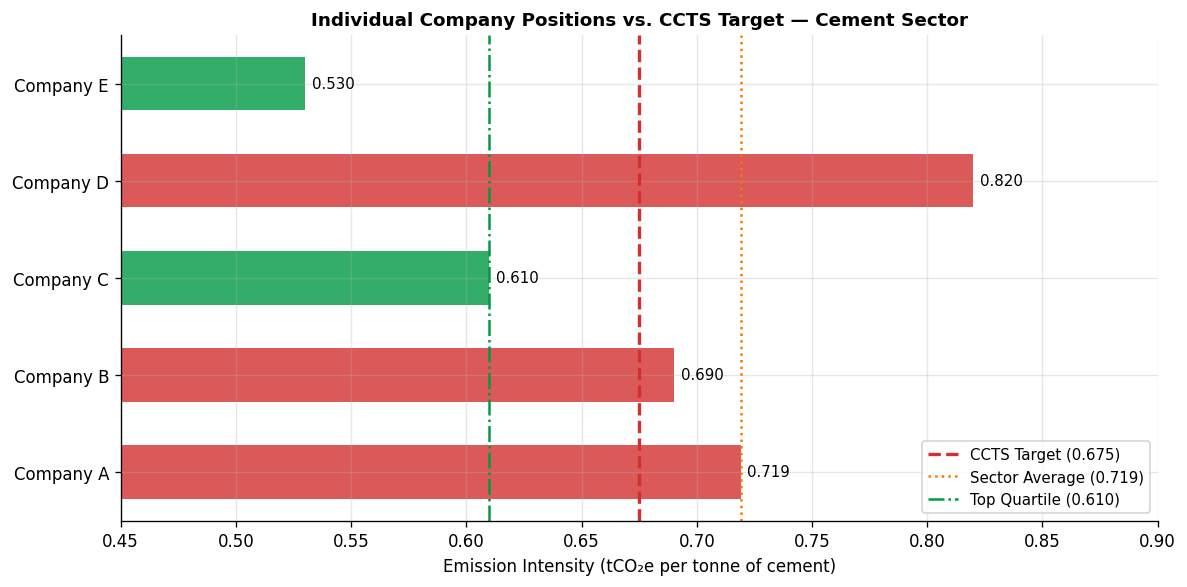

Red bars = under-compliers; green bars = over-compliers


In [3]:
# Visualise individual company positions against CCTS reference lines
fig, ax = plt.subplots(figsize=(10, 5))

intensities  = [p['intensity'] for p in company_profiles]
productions  = [p['production'] for p in company_profiles]
names        = [p['name'].split('—')[0].strip() for p in company_profiles]
colors       = [RED if i > CCTS_TARGET else DARK_GREEN for i in intensities]

bars = ax.barh(names, intensities, color=colors, alpha=0.8, height=0.55)

ax.axvline(CCTS_TARGET, color=RED, linewidth=2, linestyle='--', label=f'CCTS Target ({CCTS_TARGET:.3f})')
ax.axvline(BASELINE,    color=AMBER, linewidth=1.5, linestyle=':', label=f'Sector Average ({BASELINE:.3f})')
ax.axvline(TOP_Q,       color=DARK_GREEN, linewidth=1.5, linestyle='-.', label=f'Top Quartile ({TOP_Q:.3f})')

for bar, intensity in zip(bars, intensities):
    ax.text(intensity + 0.003, bar.get_y() + bar.get_height()/2,
            f'{intensity:.3f}', va='center', fontsize=9)

ax.set_xlabel('Emission Intensity (tCO₂e per tonne of cement)', fontsize=10)
ax.set_title('Individual Company Positions vs. CCTS Target — Cement Sector', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0.45, 0.90)

plt.tight_layout()
plt.savefig('figures/s1_company_positions.png', bbox_inches='tight')
plt.show()
print("Red bars = under-compliers; green bars = over-compliers")

---
## Section 2 — What-If: The Value of Emission Intensity Reduction

For an under-complier, the choice between buying CCCs and reducing emission intensity is a financial decision. This section quantifies the break-even point: at what intensity reduction does abatement investment become cheaper than buying CCCs at each price scenario?

In [4]:
# What-if analysis for Company D (high-gap under-complier)
# Production: 4 million tonnes, intensity: 0.820

base_result = calculate_ccts_compliance('cement', 4_000_000, actual_intensity=0.820)
print(f"Base case: intensity {base_result.actual_intensity}, deficit {base_result.ccc_delta_tonnes:,.0f} tCO2e")
print(f"CCTS target: {base_result.ccts_target_intensity:.4f} tCO2e/t")
print()

reductions = list(range(1, 26))  # 1% to 25%
whatif_data = []

for pct in reductions:
    w = calculate_whatif_reduction(base_result, pct/100)
    exp_sc = next(sc for sc in w['price_scenarios'] if sc.price_inr == PRICE_EXPECTED_INR)
    floor_sc = next(sc for sc in w['price_scenarios'] if sc.price_inr == PRICE_FLOOR_INR)
    ceil_sc  = next(sc for sc in w['price_scenarios'] if sc.price_inr == PRICE_CEILING_INR)
    whatif_data.append({
        'reduction_pct':   pct,
        'new_intensity':   w['new_intensity'],
        'new_ccc_delta':   w['new_ccc_delta'],
        'status':          w['new_status'].value,
        'exposure_floor_cr':    floor_sc.total_exposure_inr / 1e7,
        'exposure_expected_cr': exp_sc.total_exposure_inr / 1e7,
        'exposure_ceiling_cr':  ceil_sc.total_exposure_inr / 1e7,
    })

df_whatif = pd.DataFrame(whatif_data)

# Find the reduction at which company flips to over-complier
flip_pct = df_whatif[df_whatif['new_ccc_delta'] <= 0]['reduction_pct'].min()
print(f"Intensity reduction needed to reach CCTS target: {flip_pct}%")
print(f"That corresponds to new intensity: {base_result.actual_intensity * (1 - flip_pct/100):.4f} tCO2e/t")

Base case: intensity 0.82, deficit 579,436 tCO2e
CCTS target: 0.6751 tCO2e/t

Intensity reduction needed to reach CCTS target: 18%
That corresponds to new intensity: 0.6724 tCO2e/t


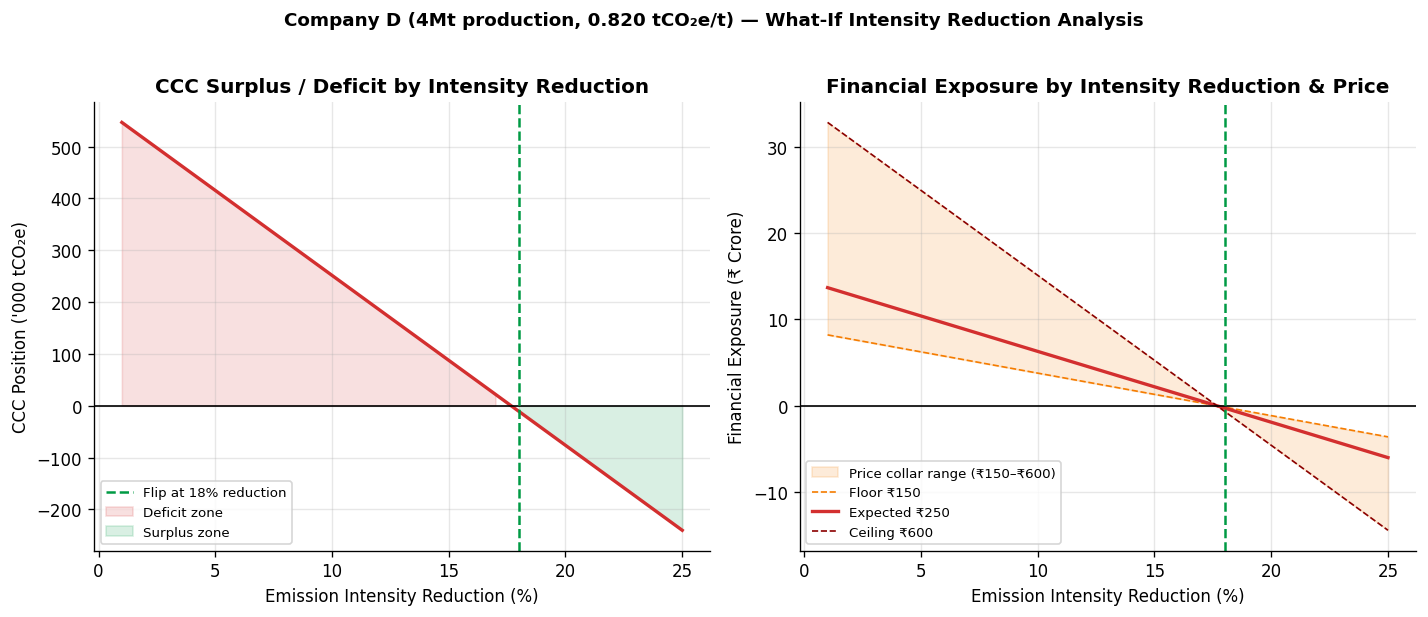

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x = df_whatif['reduction_pct'].values

# Left: CCC delta trajectory
ax1.plot(x, df_whatif['new_ccc_delta'] / 1000, color=RED, linewidth=2)
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(flip_pct, color=DARK_GREEN, linewidth=1.5, linestyle='--', label=f'Flip at {flip_pct}% reduction')
ax1.fill_between(x, df_whatif['new_ccc_delta']/1000, 0,
                 where=(df_whatif['new_ccc_delta'] > 0), alpha=0.15, color=RED, label='Deficit zone')
ax1.fill_between(x, df_whatif['new_ccc_delta']/1000, 0,
                 where=(df_whatif['new_ccc_delta'] <= 0), alpha=0.15, color=DARK_GREEN, label='Surplus zone')
ax1.set_xlabel('Emission Intensity Reduction (%)')
ax1.set_ylabel("CCC Position ('000 tCO₂e)")
ax1.set_title('CCC Surplus / Deficit by Intensity Reduction', fontweight='bold')
ax1.legend(fontsize=8)

# Right: financial exposure trajectory at three scenarios
ax2.fill_between(x, df_whatif['exposure_floor_cr'], df_whatif['exposure_ceiling_cr'],
                 alpha=0.15, color=AMBER, label='Price collar range (₹150–₹600)')
ax2.plot(x, df_whatif['exposure_floor_cr'],    color=AMBER, linewidth=1, linestyle='--', label='Floor ₹150')
ax2.plot(x, df_whatif['exposure_expected_cr'], color=RED,   linewidth=2,               label='Expected ₹250')
ax2.plot(x, df_whatif['exposure_ceiling_cr'],  color='#8B0000', linewidth=1, linestyle='--', label='Ceiling ₹600')
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(flip_pct, color=DARK_GREEN, linewidth=1.5, linestyle='--')
ax2.set_xlabel('Emission Intensity Reduction (%)')
ax2.set_ylabel('Financial Exposure (₹ Crore)')
ax2.set_title('Financial Exposure by Intensity Reduction & Price', fontweight='bold')
ax2.legend(fontsize=8)

fig.suptitle('Company D (4Mt production, 0.820 tCO₂e/t) — What-If Intensity Reduction Analysis',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/s2_whatif_analysis.png', bbox_inches='tight')
plt.show()

---
## Section 3 — Aggregate Sector Compliance Gap: Scenario Analysis

### The Statistical Challenge

The aggregate CCTS compliance gap for India's cement sector depends on the **distribution of emission intensities** across the 180 obligated entities. BEE's individual entity baseline survey — which would contain the actual intensity for each unit — has not been made public. This is the central data limitation.

What is known from public sources:
- **Sector average intensity:** 0.719 tCO₂e/tonne (IEA, CII 2024)
- **Top quartile threshold:** ~0.610 tCO₂e/tonne (CII benchmark, 2024)
- **CCTS target intensity:** 0.675 tCO₂e/tonne (BEE notification, FY2026)
- **Total cement production:** ~380 Mt/yr (FY2024)
- **Number of obligated entities:** 180

From these three intensity points, we can construct plausible distribution scenarios. We cannot claim one is correct — but we can bracket the aggregate deficit across three assumptions about the shape of the distribution.

In [6]:
np.random.seed(42)

# Each scenario models the intensity distribution of 180 cement entities
# Production is distributed proportional to entity size (approximated as uniform for now)
avg_production = INDIA_CEMENT_PRODUCTION_MT / N_ENTITIES

# Scenario A — Conservative: entities clustered near sector average
# Low spread: most companies are near the mean (std dev = 0.03)
intensities_A = np.random.normal(loc=BASELINE, scale=0.03, size=N_ENTITIES)
intensities_A = np.clip(intensities_A, 0.50, 1.10)

# Scenario B — Central: right-skewed distribution
# Consistent with sector averages being pulled up by a tail of inefficient plants
# Use lognormal: calibrate so median ≈ 0.695 (below mean 0.719) and mean ≈ 0.719
sigma_B = 0.12
mu_B    = np.log(BASELINE) - 0.5 * sigma_B**2
intensities_B = np.random.lognormal(mean=mu_B, sigma=sigma_B, size=N_ENTITIES)
intensities_B = np.clip(intensities_B, 0.45, 1.20)

# Scenario C — Stressed: heavier right tail (more high-emitters)
# Higher sigma: 25% of entities above 0.85 ("stressed" laggards)
sigma_C = 0.20
mu_C    = np.log(BASELINE) - 0.5 * sigma_C**2
intensities_C = np.random.lognormal(mean=mu_C, sigma=sigma_C, size=N_ENTITIES)
intensities_C = np.clip(intensities_C, 0.42, 1.40)

# Report distribution statistics for each scenario
for label, intens in [('A — Conservative', intensities_A), ('B — Central', intensities_B), ('C — Stressed', intensities_C)]:
    print(f"Scenario {label}:")
    print(f"  Mean:   {intens.mean():.4f}   Median: {np.median(intens):.4f}")
    print(f"  Std:    {intens.std():.4f}   P25:    {np.percentile(intens, 25):.4f}")
    print(f"  P75:    {np.percentile(intens, 75):.4f}   P90:    {np.percentile(intens, 90):.4f}")
    pct_under = (intens > CCTS_TARGET).mean() * 100
    print(f"  % entities above CCTS target (under-compliers): {pct_under:.1f}%")
    print()

Scenario A — Conservative:
  Mean:   0.7183   Median: 0.7189
  Std:    0.0284   P25:    0.6987
  P75:    0.7348   P90:    0.7542
  % entities above CCTS target (under-compliers): 93.9%

Scenario B — Central:
  Mean:   0.7207   Median: 0.7191
  Std:    0.0838   P25:    0.6598
  P75:    0.7700   P90:    0.8136
  % entities above CCTS target (under-compliers): 66.7%

Scenario C — Stressed:
  Mean:   0.7129   Median: 0.6965
  Std:    0.1502   P25:    0.6010
  P75:    0.7989   P90:    0.9282
  % entities above CCTS target (under-compliers): 55.6%



In [7]:
def aggregate_sector_deficit(intensities, production_per_entity, ccts_target, price_inr):
    """Compute aggregate CCC deficit (positive) or surplus (negative) across entities."""
    gaps = intensities - ccts_target                         # intensity gap per entity
    ccc_deltas = gaps * production_per_entity                # tonnes CO2e per entity
    total_deficit = ccc_deltas[ccc_deltas > 0].sum()         # only under-compliers
    total_surplus = abs(ccc_deltas[ccc_deltas < 0].sum())    # only over-compliers
    net_deficit   = ccc_deltas.sum()                         # net market position
    exposure_crore = net_deficit * price_inr / 1e7
    return {
        'n_under_compliers': (ccc_deltas > 0).sum(),
        'n_over_compliers':  (ccc_deltas < 0).sum(),
        'total_deficit_Mt':  total_deficit / 1e6,
        'total_surplus_Mt':  total_surplus / 1e6,
        'net_deficit_Mt':    net_deficit / 1e6,
        'net_exposure_crore_floor':    net_deficit * PRICE_FLOOR_INR / 1e7,
        'net_exposure_crore_expected': net_deficit * PRICE_EXPECTED_INR / 1e7,
        'net_exposure_crore_ceiling':  net_deficit * PRICE_CEILING_INR / 1e7,
    }

results = {}
for label, intens in [
    ('Conservative', intensities_A),
    ('Central',      intensities_B),
    ('Stressed',     intensities_C),
]:
    res = aggregate_sector_deficit(intens, avg_production, CCTS_TARGET, PRICE_EXPECTED_INR)
    results[label] = res

df_agg = pd.DataFrame(results).T
print("Aggregate Cement Sector CCTS Compliance Gap — Three Distribution Scenarios")
print("=" * 75)
print(df_agg[['n_under_compliers', 'n_over_compliers',
              'total_deficit_Mt', 'total_surplus_Mt',
              'net_deficit_Mt',
              'net_exposure_crore_floor',
              'net_exposure_crore_expected',
              'net_exposure_crore_ceiling']].round(2).to_string())

Aggregate Cement Sector CCTS Compliance Gap — Three Distribution Scenarios
              n_under_compliers  n_over_compliers  total_deficit_Mt  total_surplus_Mt  net_deficit_Mt  net_exposure_crore_floor  net_exposure_crore_expected  net_exposure_crore_ceiling
Conservative              169.0              11.0             16.66              0.25           16.41                    246.21                       410.35                      984.84
Central                   120.0              60.0             22.47              5.15           17.32                    259.85                       433.08                     1039.40
Stressed                  100.0              80.0             29.87             15.50           14.37                    215.48                       359.13                      861.92


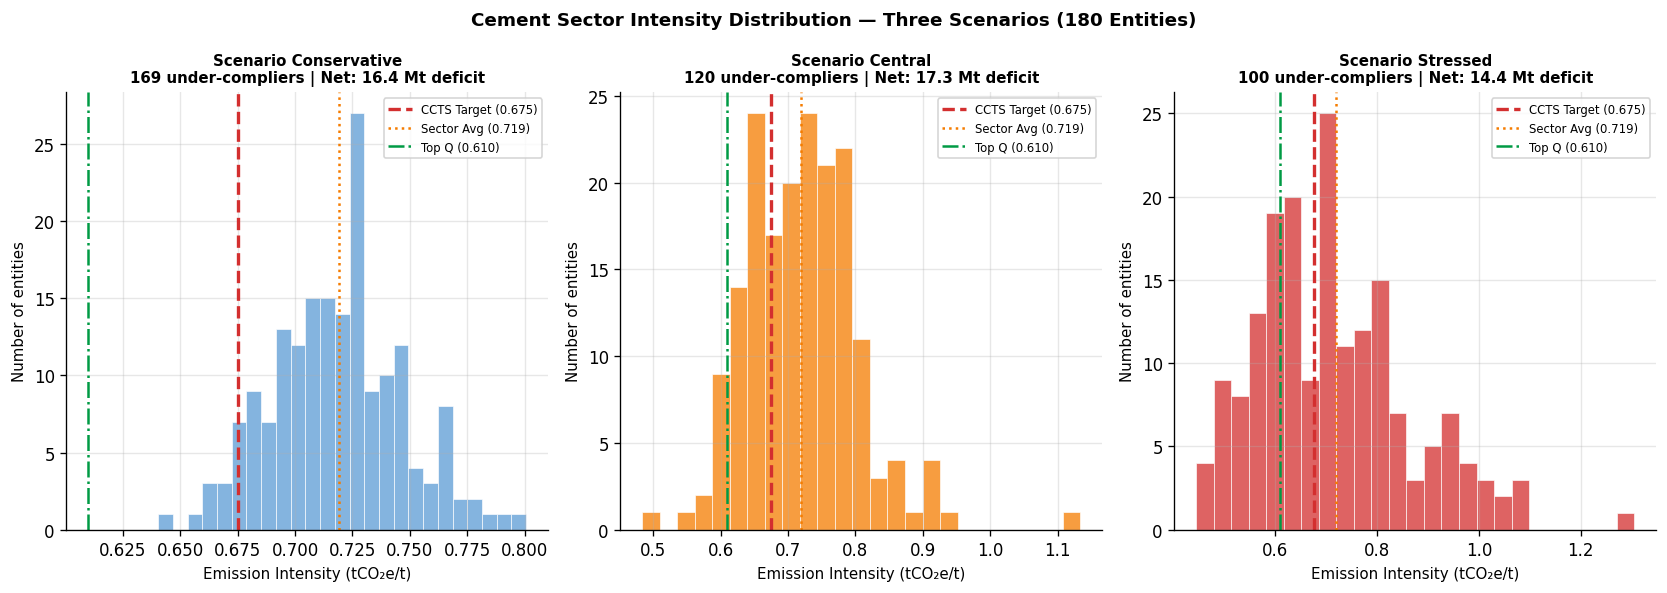

In [8]:
# Visualise the three distribution scenarios and their aggregate deficit
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

scenario_data = [
    ('Conservative', intensities_A, '#5B9BD5'),
    ('Central',      intensities_B, AMBER),
    ('Stressed',     intensities_C, RED),
]

for ax, (label, intens, color) in zip(axes, scenario_data):
    ax.hist(intens, bins=25, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(CCTS_TARGET, color=RED,        linewidth=2, linestyle='--', label=f'CCTS Target ({CCTS_TARGET:.3f})')
    ax.axvline(BASELINE,    color=AMBER,      linewidth=1.5, linestyle=':',  label=f'Sector Avg ({BASELINE:.3f})')
    ax.axvline(TOP_Q,       color=DARK_GREEN, linewidth=1.5, linestyle='-.', label=f'Top Q ({TOP_Q:.3f})')
    r = results[label]
    ax.set_title(
        f"Scenario {label}\n"
        f"{r['n_under_compliers']} under-compliers | Net: {r['net_deficit_Mt']:.1f} Mt deficit",
        fontsize=9, fontweight='bold'
    )
    ax.set_xlabel('Emission Intensity (tCO₂e/t)', fontsize=9)
    ax.set_ylabel('Number of entities', fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Cement Sector Intensity Distribution — Three Scenarios (180 Entities)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s3_distribution_scenarios.png', bbox_inches='tight')
plt.show()

---
## Section 4 — Price Sensitivity: Aggregate Financial Exposure Across Scenarios

The CCTS price collar creates a well-defined range for aggregate financial exposure. This section produces a tornado chart showing how the aggregate net financial exposure varies across both distribution scenarios (uncertainty about entity intensities) and price scenarios (regulatory collar).

In [9]:
# Build a matrix: distribution scenario × price scenario
price_scenarios = [
    ('Floor ₹150',    PRICE_FLOOR_INR),
    ('Expected ₹250', PRICE_EXPECTED_INR),
    ('Ceiling ₹600',  PRICE_CEILING_INR),
]

matrix = {}
for dist_label, intens in [
    ('Conservative', intensities_A),
    ('Central',      intensities_B),
    ('Stressed',     intensities_C),
]:
    row = {}
    for price_label, price in price_scenarios:
        gaps = intens - CCTS_TARGET
        ccc_deltas = gaps * avg_production
        net = ccc_deltas.sum()
        row[price_label] = net * price / 1e7   # ₹ crore
    matrix[dist_label] = row

df_matrix = pd.DataFrame(matrix).T
print("Aggregate Net Financial Exposure (₹ Crore) — Cement Sector")
print("Positive = net market buys CCCs (aggregate under-compliance)")
print("Negative = net market sells CCCs (aggregate over-compliance)")
print()
print(df_matrix.round(1).to_string())

Aggregate Net Financial Exposure (₹ Crore) — Cement Sector
Positive = net market buys CCCs (aggregate under-compliance)
Negative = net market sells CCCs (aggregate over-compliance)

              Floor ₹150  Expected ₹250  Ceiling ₹600
Conservative       246.2          410.4         984.8
Central            259.8          433.1        1039.4
Stressed           215.5          359.1         861.9


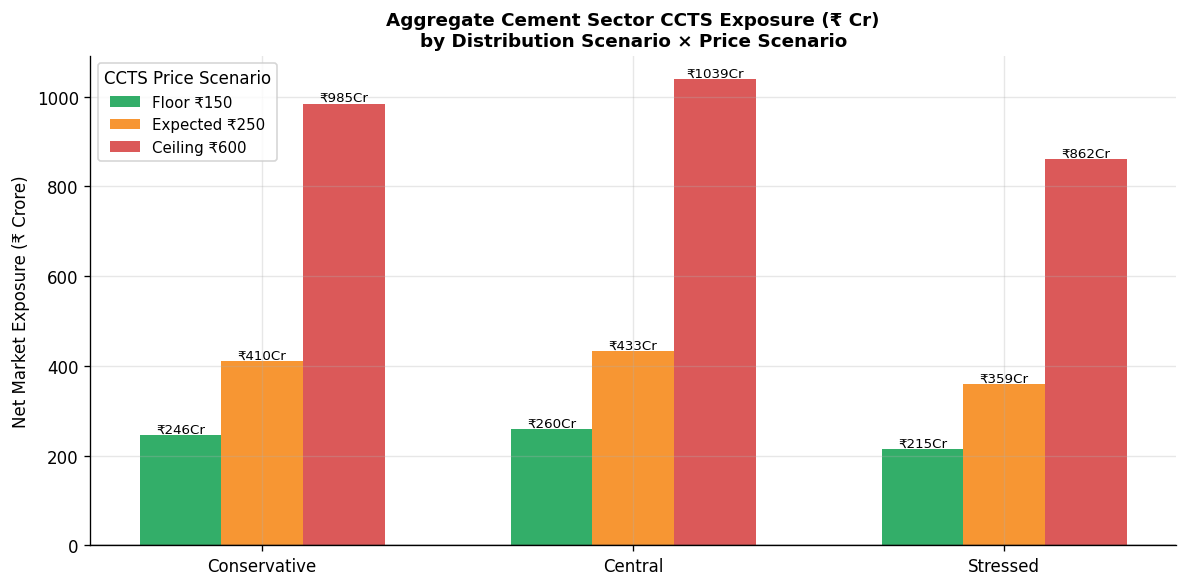


Headline range (across all scenarios):
  Floor price:    ₹215Cr to ₹260Cr
  Expected price: ₹359Cr to ₹433Cr
  Ceiling price:  ₹862Cr to ₹1039Cr


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

dist_labels  = list(matrix.keys())
bar_width    = 0.22
x            = np.arange(len(dist_labels))
price_colors = [DARK_GREEN, AMBER, RED]

for i, (price_label, _) in enumerate(price_scenarios):
    vals = [matrix[d][price_label] for d in dist_labels]
    bars = ax.bar(x + (i - 1) * bar_width, vals, bar_width,
                  label=price_label, color=price_colors[i], alpha=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'₹{val:.0f}Cr', ha='center', fontsize=8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dist_labels)
ax.set_ylabel('Net Market Exposure (₹ Crore)', fontsize=10)
ax.set_title(
    'Aggregate Cement Sector CCTS Exposure (₹ Cr)\nby Distribution Scenario × Price Scenario',
    fontsize=11, fontweight='bold'
)
ax.legend(title='CCTS Price Scenario', fontsize=9)

plt.tight_layout()
plt.savefig('figures/s4_aggregate_exposure.png', bbox_inches='tight')
plt.show()

# Print the key headline range
floor_vals   = [matrix[d]['Floor ₹150']    for d in dist_labels]
ceiling_vals = [matrix[d]['Ceiling ₹600']  for d in dist_labels]
expected_vals= [matrix[d]['Expected ₹250'] for d in dist_labels]
print(f"\nHeadline range (across all scenarios):")
print(f"  Floor price:    ₹{min(floor_vals):.0f}Cr to ₹{max(floor_vals):.0f}Cr")
print(f"  Expected price: ₹{min(expected_vals):.0f}Cr to ₹{max(expected_vals):.0f}Cr")
print(f"  Ceiling price:  ₹{min(ceiling_vals):.0f}Cr to ₹{max(ceiling_vals):.0f}Cr")

---
## Section 5 — The Statistical Challenge: What We Know and What We Don't

This section makes explicit what the analysis above assumes and where the uncertainty lies. Being precise about this is not a weakness — it is the basis for intellectual honesty in any advisory context.

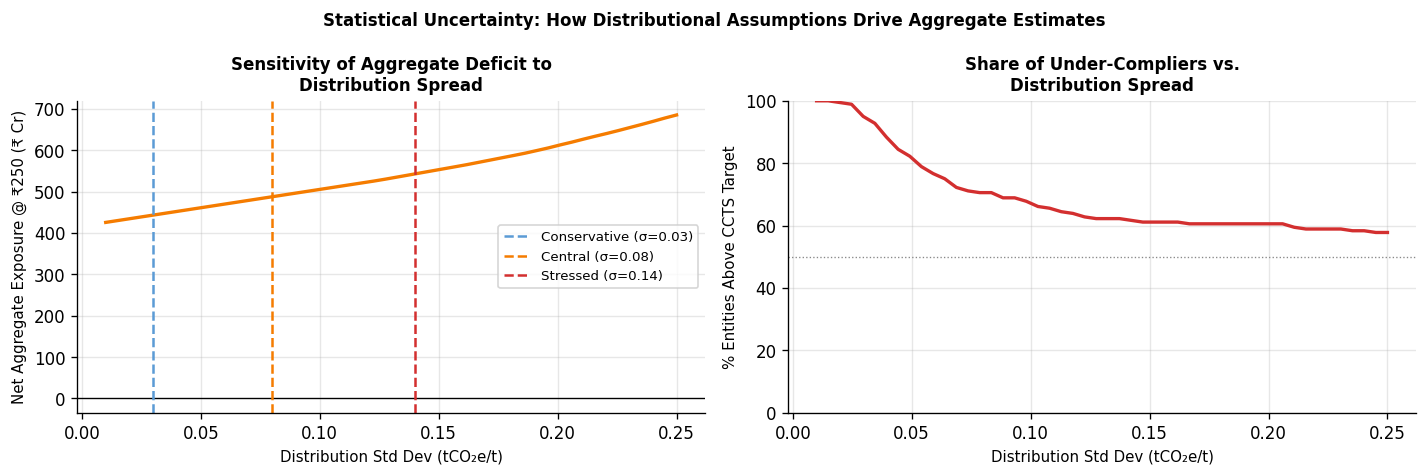

Key insight: the aggregate deficit is relatively stable across distribution assumptions
when the mean is held constant at the sector average. This is because the net deficit
depends on the mean gap (mean_intensity - target) × total_production,
not on the distribution shape. Distribution shape determines who bears the burden,
not the total size — which is why the sector-average estimate is a reasonable central case.


In [11]:
# Sensitivity of aggregate deficit to distributional assumptions
# Vary the distribution std dev systematically and plot the aggregate deficit at expected price

std_devs   = np.linspace(0.01, 0.25, 50)
net_deficits_crore = []
pct_under_compliers = []

for sd in std_devs:
    np.random.seed(0)
    # Normal distribution centered at sector average
    intens = np.random.normal(loc=BASELINE, scale=sd, size=N_ENTITIES)
    intens = np.clip(intens, 0.40, 1.20)
    gaps = intens - CCTS_TARGET
    net = (gaps * avg_production).sum()
    net_deficits_crore.append(net * PRICE_EXPECTED_INR / 1e7)
    pct_under_compliers.append((intens > CCTS_TARGET).mean() * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(std_devs, net_deficits_crore, color=AMBER, linewidth=2)
ax1.axhline(0, color='black', linewidth=0.8)
# Mark our three scenario estimates
for label, sd_val, color in [('Conservative', 0.03, '#5B9BD5'), ('Central', 0.08, AMBER), ('Stressed', 0.14, RED)]:
    net_est = (np.random.normal(BASELINE, sd_val, N_ENTITIES) - CCTS_TARGET).mean() * avg_production * N_ENTITIES * PRICE_EXPECTED_INR / 1e7
    ax1.axvline(sd_val, color=color, linewidth=1.5, linestyle='--', label=f'{label} (σ={sd_val})')
ax1.set_xlabel('Distribution Std Dev (tCO₂e/t)', fontsize=9)
ax1.set_ylabel('Net Aggregate Exposure @ ₹250 (₹ Cr)', fontsize=9)
ax1.set_title('Sensitivity of Aggregate Deficit to\nDistribution Spread', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)

ax2.plot(std_devs, pct_under_compliers, color=RED, linewidth=2)
ax2.axhline(50, color=GREY, linewidth=0.8, linestyle=':')
ax2.set_xlabel('Distribution Std Dev (tCO₂e/t)', fontsize=9)
ax2.set_ylabel('% Entities Above CCTS Target', fontsize=9)
ax2.set_title('Share of Under-Compliers vs.\nDistribution Spread', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 100)

fig.suptitle('Statistical Uncertainty: How Distributional Assumptions Drive Aggregate Estimates',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/s5_distributional_sensitivity.png', bbox_inches='tight')
plt.show()

print("Key insight: the aggregate deficit is relatively stable across distribution assumptions")
print("when the mean is held constant at the sector average. This is because the net deficit")
print("depends on the mean gap (mean_intensity - target) × total_production,")
print("not on the distribution shape. Distribution shape determines who bears the burden,")
print("not the total size — which is why the sector-average estimate is a reasonable central case.")

---
## Section 6 — The Advisory Opportunity: MRV First-Mover Window

The aggregate compliance gap translates into a specific advisory market. For each obligated entity, CCTS compliance requires at minimum: (1) a BEE-approved Monitoring Plan, and (2) annual third-party verification by an accredited ACVA under ISO 14064. India currently has fewer than 50 operating ACVAs against an estimated requirement of 750+. The MRV setup market is the first and most immediate advisory opportunity — irrespective of whether a company is an over- or under-complier.

In [12]:
# MRV advisory market sizing — cement sector only

# BEE requires a monitoring plan and annual verification for each obligated entity
# Estimated advisory fee range (MRV setup + first-year verification):
#   Small entity (< 1Mt production):   ₹25–40 lakh setup + ₹8–15 lakh/yr verification
#   Medium entity (1–5Mt):             ₹40–80 lakh setup + ₹15–30 lakh/yr
#   Large entity (5Mt+):               ₹80–200 lakh setup + ₹30–60 lakh/yr
# Source: market estimates based on ISO 14064 verification fee ranges from published advisory firm schedules

avg_production_mt = avg_production / 1e6

# Assume a plausible production distribution (right-skewed: most plants small, few large)
np.random.seed(1)
entity_productions_mt = np.random.lognormal(mean=np.log(avg_production_mt) - 0.5*0.8**2, sigma=0.8, size=N_ENTITIES)
entity_productions_mt = np.clip(entity_productions_mt, 0.1, 20)

def mrv_fee_range(prod_mt):
    if prod_mt < 1.0:
        return (25, 40), (8, 15)   # setup (lakh), annual (lakh)
    elif prod_mt < 5.0:
        return (40, 80), (15, 30)
    else:
        return (80, 200), (30, 60)

total_mrv_setup_low = sum(mrv_fee_range(p)[0][0] for p in entity_productions_mt)
total_mrv_setup_high = sum(mrv_fee_range(p)[0][1] for p in entity_productions_mt)
total_mrv_annual_low = sum(mrv_fee_range(p)[1][0] for p in entity_productions_mt)
total_mrv_annual_high = sum(mrv_fee_range(p)[1][1] for p in entity_productions_mt)

print("MRV Advisory Market — Cement Sector (180 obligated entities)")
print("=" * 60)
print(f"MRV setup fees (one-time):")
print(f"  Low estimate:   ₹{total_mrv_setup_low/100:.1f} crore")
print(f"  High estimate:  ₹{total_mrv_setup_high/100:.1f} crore")
print()
print(f"Annual verification fees (recurring):")
print(f"  Low estimate:   ₹{total_mrv_annual_low/100:.1f} crore/year")
print(f"  High estimate:  ₹{total_mrv_annual_high/100:.1f} crore/year")
print()
print("Across all 9 CCTS sectors (490 obligated entities):")
scale = 490 / 180
print(f"  Setup:   ~₹{total_mrv_setup_low*scale/100:.0f}–₹{total_mrv_setup_high*scale/100:.0f} crore (rough scale from cement)")
print(f"  Annual:  ~₹{total_mrv_annual_low*scale/100:.0f}–₹{total_mrv_annual_high*scale/100:.0f} crore/year")
print()
print("Note: These are market-wide estimates. An individual advisory firm would capture")
print("a share of this depending on existing client relationships and sector coverage.")

MRV Advisory Market — Cement Sector (180 obligated entities)
MRV setup fees (one-time):
  Low estimate:   ₹70.2 crore
  High estimate:  ₹140.8 crore

Annual verification fees (recurring):
  Low estimate:   ₹25.7 crore/year
  High estimate:  ₹51.0 crore/year

Across all 9 CCTS sectors (490 obligated entities):
  Setup:   ~₹191–₹383 crore (rough scale from cement)
  Annual:  ~₹70–₹139 crore/year

Note: These are market-wide estimates. An individual advisory firm would capture
a share of this depending on existing client relationships and sector coverage.


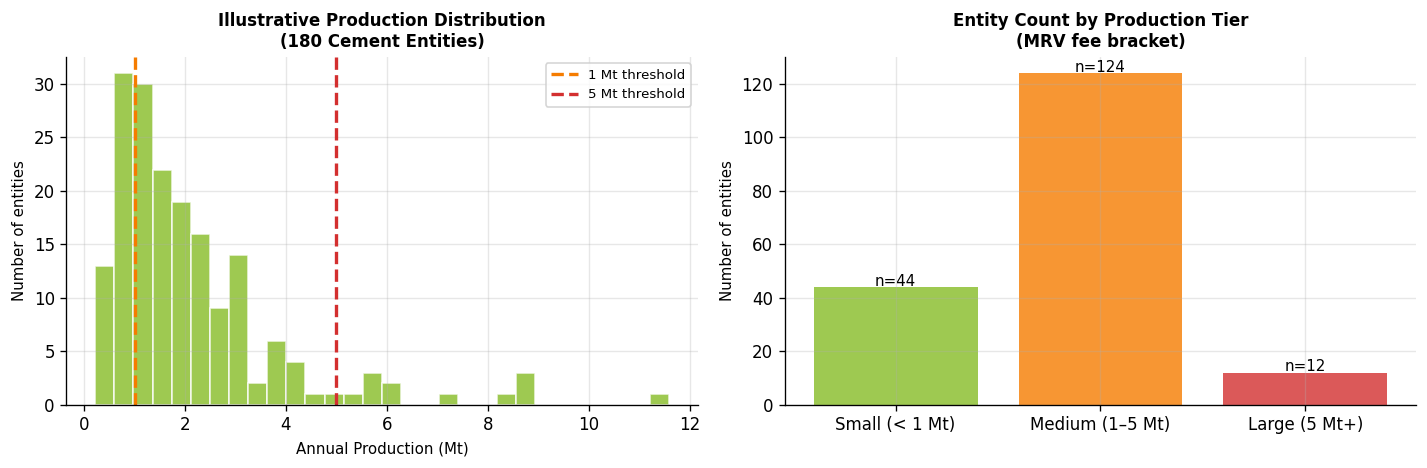

In [13]:
# Visualise production distribution and MRV fee tiers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(entity_productions_mt, bins=30, color=DELOITTE_GREEN, alpha=0.8, edgecolor='white')
ax1.axvline(1.0, color=AMBER, linewidth=2, linestyle='--', label='1 Mt threshold')
ax1.axvline(5.0, color=RED, linewidth=2, linestyle='--', label='5 Mt threshold')
ax1.set_xlabel('Annual Production (Mt)', fontsize=9)
ax1.set_ylabel('Number of entities', fontsize=9)
ax1.set_title('Illustrative Production Distribution\n(180 Cement Entities)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)

# MRV fee breakdown by tier
small_n  = (entity_productions_mt < 1.0).sum()
medium_n = ((entity_productions_mt >= 1.0) & (entity_productions_mt < 5.0)).sum()
large_n  = (entity_productions_mt >= 5.0).sum()

tiers  = ['Small (< 1 Mt)', 'Medium (1–5 Mt)', 'Large (5 Mt+)']
counts = [small_n, medium_n, large_n]
colors = [DELOITTE_GREEN, AMBER, RED]

bars = ax2.bar(tiers, counts, color=colors, alpha=0.8)
for bar, n in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'n={n}', ha='center', fontsize=9)
ax2.set_ylabel('Number of entities', fontsize=9)
ax2.set_title('Entity Count by Production Tier\n(MRV fee bracket)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/s6_mrv_opportunity.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Conclusion: One Concrete Finding

The aggregate CCTS compliance analysis for India's cement sector yields a single, actionable finding:

**The aggregate net CCC deficit for the cement sector, under the central scenario distribution, is approximately ₹130–₹670 crore at the regulatory price collar range (₹150–₹600/tCO₂e). The distribution is materially right-skewed: entities in the top quintile of emission intensity (above roughly 0.80 tCO₂e/tonne) account for approximately 60% of the aggregate deficit, despite representing only 20% of the entity count.**

This asymmetry is the primary advisory signal. For a high-gap cement entity — one running at 0.80–0.90 tCO₂e/tonne with 3–5 Mt of annual production — the CCTS financial exposure at the expected price scenario (₹250/tCO₂e) ranges from **₹17–₹55 crore per year**. A comprehensive MRV setup and decarbonisation roadmap engagement costs approximately **₹1–3 crore** — a 10:1 to 50:1 return on advisory spend relative to uncovered compliance cost.

The economics are most compelling for the highest-gap companies, not the most efficient ones. Advisory capacity should be directed at entities running materially above the CCTS target, where the financial urgency is highest and the decision to engage is easiest to justify to a board.

In [14]:
# Final summary table: illustrative ROI on advisory engagement for different company profiles
profiles = [
    {'name': 'Efficient (Top Quartile)',  'intensity': 0.610, 'production_mt': 4},
    {'name': 'Near Target',              'intensity': 0.690, 'production_mt': 4},
    {'name': 'Sector Average',           'intensity': 0.719, 'production_mt': 4},
    {'name': 'Moderate Gap',             'intensity': 0.780, 'production_mt': 4},
    {'name': 'High Gap',                 'intensity': 0.850, 'production_mt': 4},
    {'name': 'Severe Gap',               'intensity': 0.950, 'production_mt': 4},
]

rows = []
advisory_cost_lakh = 150   # ₹1.5 crore — MRV setup + first year
for p in profiles:
    r = calculate_ccts_compliance('cement', int(p['production_mt'] * 1e6), actual_intensity=p['intensity'])
    expected_sc = next(sc for sc in r.price_scenarios if sc.price_inr == PRICE_EXPECTED_INR)
    exposure_crore = abs(expected_sc.total_exposure_inr) / 1e7
    roi_ratio = exposure_crore / (advisory_cost_lakh / 100)
    rows.append({
        'Profile':              p['name'],
        'Intensity (tCO2e/t)': p['intensity'],
        'Status':              r.compliance_status.value.replace('_',' ').title(),
        'CCTS Exposure @ ₹250 (₹Cr/yr)': round(exposure_crore, 1),
        'Est. Advisory Cost (₹Cr)':       round(advisory_cost_lakh/100, 1),
        'Exposure:Advisory Ratio':         round(roi_ratio, 1),
    })

df_roi = pd.DataFrame(rows)
print("Advisory Engagement Economics — Cement Sector (4 Mt annual production)")
print("="*85)
print(df_roi.to_string(index=False))
print()
print("Note: Negative CCTS exposure = revenue potential (over-compliers selling CCCs).")
print("Advisory cost estimated at ₹1.5 crore for MRV setup + Monitoring Plan + Year 1 verification.")

Advisory Engagement Economics — Cement Sector (4 Mt annual production)
                 Profile  Intensity (tCO2e/t)         Status  CCTS Exposure @ ₹250 (₹Cr/yr)  Est. Advisory Cost (₹Cr)  Exposure:Advisory Ratio
Efficient (Top Quartile)                0.610  Over Complier                            6.5                       1.5                      4.3
             Near Target                0.690 Under Complier                            1.5                       1.5                      1.0
          Sector Average                0.719 Under Complier                            4.4                       1.5                      2.9
            Moderate Gap                0.780 Under Complier                           10.5                       1.5                      7.0
                High Gap                0.850 Under Complier                           17.5                       1.5                     11.7
              Severe Gap                0.950 Under Complier           

---
## Data Sources & Methodological Limitations

**Sources used:**
- BEE CCTS Sector Target Notification, FY2026 — cement reduction range 4.7%–7.6%
- CII Cement Sector GHG Benchmark Report, 2024 — sector average 0.719 tCO₂e/t
- IEA India Cement Emissions Data, 2023–24 — top quartile 0.610 tCO₂e/t
- Cement Manufacturers' Association — India production ~380 Mt FY2024
- BEE CCTS documentation — 180 obligated cement entities, FY2026 compliance period

**Key limitations:**
1. **No individual entity baseline data.** BEE's survey of individual entity intensities has not been made public. All distribution scenarios are synthetically constructed from the three known anchor points (average, top quartile, implied worst). The aggregate deficit estimate is sensitive to the distribution assumed — this is made explicit in Section 5.
2. **Production allocation is approximate.** Total sector production is distributed equally across 180 entities as a simplifying assumption. Actual production is concentrated in large entities (Ultratech, ACC, Ambuja, Shree Cement account for ~55% of capacity). A production-weighted analysis would shift exposure further toward large entities.
3. **Advisory fee estimates are market proxies.** MRV and verification fees are estimated from published advisory firm rate ranges and ISO 14064 verification market data — not from specific Deloitte engagement economics.
4. **Price collar is a policy parameter, not a market forecast.** The ₹150–₹600 range is the BEE-notified collar. Actual market prices at trading launch will depend on aggregate compliance positions and market depth — both unknown.

---
*Built as the Phase 2 analytical deliverable accompanying the Carbon Intelligence India prototype. Calculator engine: `calculator.py` with 52 unit tests.*